<a href="https://colab.research.google.com/github/ayaaayaaayaaayaaayaaayaa/1G3k6bk3eE5jS72tEbvvYEclhIGrEHNuA/blob/main/Improvements(V2_0)_(B_AND_G)_%D9%87%D8%B0%D9%87_%D8%A7%D9%84%D9%86%D8%B3%D8%AE%D8%A9_%D9%87%D9%8A_%D9%85%D8%B9%D8%AA%D9%85%D8%AF%D8%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# تحسينات هدف (ب) على كود تنظيف البيانات

In [ ]:
import pandas as pd
import numpy as np

# تحميل البيانات
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# إنشاء نسخة قبل التحسين
df_before = df.copy()

# ------------------- تنظيف وتحسين البيانات -------------------

# تحويل عمود التاريخ إلى صيغة تاريخ صحيحة
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# استبدال القيم غير المعروفة أو الخاطئة بقيم مفقودة
df.replace(["UNKNOWN", "Unknown", "ERROR", "Error"], np.nan, inplace=True)

# تحويل الأعمدة الرقمية إلى أرقام
numeric_columns = ["Quantity", "Price Per Unit", "Total Spent"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# حذف الصفوف التي تحتوي على بيانات أساسية مفقودة
df.dropna(subset=["Transaction Date", "Item", "Quantity"], inplace=True)

# تعويض القيم المفقودة في الأعمدة النصية بالقيمة الأكثر تكرارًا
df["Payment Method"] = df["Payment Method"].fillna(df["Payment Method"].mode()[0])
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

# حذف القيم غير المنطقية مثل القيم السالبة أو الصفرية
df = df[(df["Quantity"] > 0) & (df["Price Per Unit"] > 0)]

# إعادة حساب إجمالي الإنفاق
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

# تحسين 1: توحيد أسماء المنتجات
df["Item"] = df["Item"].str.strip().str.lower()

# تحسين 2: إضافة أعمدة زمنية للتحليل
df['Day'] = df['Transaction Date'].dt.day_name()
df['Month'] = df['Transaction Date'].dt.month
df['Hour'] = df['Transaction Date'].dt.hour

# تحسين 3: كشف ومعالجة القيم المتطرفة (إزالة أعلى 1٪)
df = df[df['Total Spent'] < df['Total Spent'].quantile(0.99)]

# تحسين 4: إضافة أعمدة مشتقة للتحليل المالي (فئة السعر)
bins = [0, 5, 10, 20, 50, 1000]
labels = ['0-5','5-10','10-20','20-50','50+']
df['Price Category'] = pd.cut(df['Total Spent'], bins=bins, labels=labels)

# تحسين 5: إعداد مجموعات تحليلية جاهزة
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum().reset_index()
item_sales = df.groupby('Item')['Total Spent'].sum().reset_index()
payment_sales = df.groupby('Payment Method')['Total Spent'].sum().reset_index()
hourly_sales = df.groupby('Hour')['Total Spent'].sum().reset_index()
day_sales = df.groupby('Day')['Total Spent'].sum().reset_index()

# تحسين 6: إعادة حساب إجمالي الإنفاق بعد كل التعديلات
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]
#  عرض الجداول قبل وبعد التحسين
print("جدول قبل التحسين (أول 10 صفوف)")
display(df_before.head(10))

print("جدول بعد التحسين (أول 10 صفوف)")
display(df.head(10))



جدول قبل التحسين (أول 10 صفوف)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31
6,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28
7,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31
8,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
9,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03


جدول بعد التحسين (أول 10 صفوف)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day,Month,Hour,Price Category
0,TXN_1961373,coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,9,0,0-5
1,TXN_4977031,cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,5,0,10-20
2,TXN_4271903,cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,7,0,0-5
3,TXN_7034554,salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,Thursday,4,0,5-10
4,TXN_3160411,coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,6,0,0-5
5,TXN_2602893,smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31,Friday,3,0,10-20
6,TXN_6699534,sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28,Saturday,10,0,10-20
7,TXN_2064365,sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31,Sunday,12,0,10-20
9,TXN_7619095,sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,Wednesday,5,0,5-10
10,TXN_9437049,cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-06-01,Thursday,6,0,0-5


In [ ]:
# ملاحظة مهمة : تم الاستعانه بهذا كود من مصادر خارجية للتأكد من جودة كود
# تحويل الأعمدة الرقمية إلى أرقام قبل التحقق

numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_cols:
    df_before[col] = pd.to_numeric(df_before[col], errors='coerce')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# الآن يمكن حساب مؤشرات الجودة بدون أخطاء
missing_before = df_before.isna().sum()
missing_after = df.isna().sum()

negative_before = (df_before[["Quantity","Price Per Unit"]] < 0).sum()
negative_after = (df[["Quantity","Price Per Unit"]] < 0).sum()

invalid_total_before = (df_before["Total Spent"] != df_before["Quantity"]*df_before["Price Per Unit"]).sum()
invalid_total_after = (df["Total Spent"] != df["Quantity"]*df["Price Per Unit"]).sum()

print("إثبات جودة الكود المحسن لمبيعات المقاهي")
print("عدد القيم المفقودة قبل التحسين:\n", missing_before)
print("عدد القيم المفقودة بعد التحسين:\n", missing_after)
print("عدد القيم السالبة قبل التحسين:\n", negative_before)
print("عدد القيم السالبة بعد التحسين:\n", negative_after)
print("عدد القيم غير الصحيحة لإجمالي الإنفاق قبل التحسين:\n", invalid_total_before)
print("عدد القيم غير الصحيحة لإجمالي الإنفاق بعد التحسين:\n", invalid_total_after)

إثبات جودة الكود المحسن لمبيعات المقاهي
عدد القيم المفقودة قبل التحسين:
 Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64
عدد القيم المفقودة بعد التحسين:
 Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Day                 0
Month               0
Hour                0
Price Category      0
dtype: int64
عدد القيم السالبة قبل التحسين:
 Quantity          0
Price Per Unit    0
dtype: int64
عدد القيم السالبة بعد التحسين:
 Quantity          0
Price Per Unit    0
dtype: int64
عدد القيم غير الصحيحة لإجمالي الإنفاق قبل التحسين:
 1456
عدد القيم غير الصحيحة لإجمالي الإنفاق بعد التحسين:
 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# تحسينات على كود خوازرميات هدف (ج)

# تحسينات على خوارزمية  LinearRegression

Mean Squared Error: 0.0010889664559895523
R² Score: 0.999969556003452
Cross-Validation R² Scores: [0.99995878 0.99991953 0.99998497 0.99995099 0.99996915]
Average CV R²: 0.9999566826457942


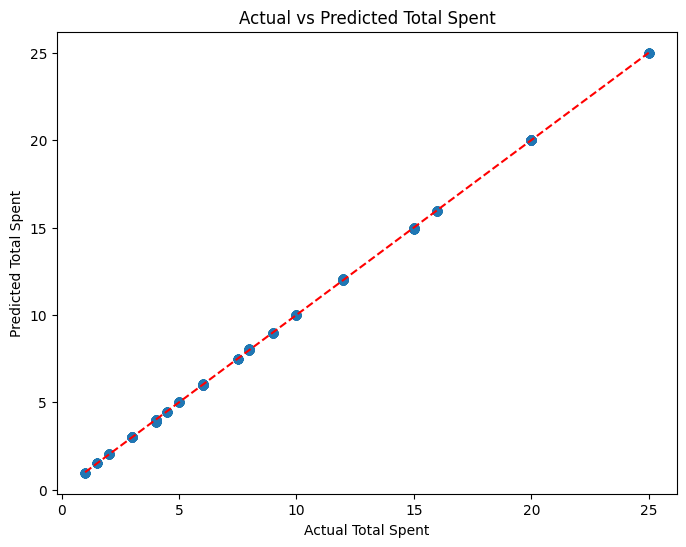

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

# أخذ نسخة من البيانات المحسنة مسبقًا
df_model = df.copy()

# تحويل الأعمدة الرقمية إلى أرقام للتأكد من صحة العمليات الحسابية
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# حذف الصفوف التي تحتوي على قيم مفقودة في الأعمدة الأساسية
df_model.dropna(subset=["Quantity", "Price Per Unit", "Total Spent"], inplace=True)

# تحويل عمود التاريخ إلى صيغة تاريخ صحيحة قبل استخراج الميزات الزمنية
df_model['Transaction Date'] = pd.to_datetime(df_model['Transaction Date'], errors='coerce')
df_model.dropna(subset=['Transaction Date'], inplace=True)

# التحسين 1: الميزات الزمنية
df_model['Day'] = df_model['Transaction Date'].dt.dayofweek
df_model['Hour'] = df_model['Transaction Date'].dt.hour

# التحسين 2: تحويل اسم المنتج إلى Dummy
df_model = pd.get_dummies(df_model, columns=['Item'], drop_first=True)

# التحسين 3: توحيد القيم العددية
scaler = StandardScaler()
df_model[['Quantity', 'Price Per Unit', 'Day', 'Hour']] = scaler.fit_transform(
    df_model[['Quantity', 'Price Per Unit', 'Day', 'Hour']]
)

# التحسين 4: استخدام نموذج أقوى
model = GradientBoostingRegressor(random_state=42)

# التحسين 5: إضافة متوسط سعر الوحدة اليومي
df_model['Daily_Avg_Price'] = df_model.groupby(df_model['Transaction Date'].dt.date)['Price Per Unit'].transform('mean')

# التحسين 6: إضافة إجمالي الإنفاق السابق لكل صف
df_model['Prev_Total_Spent'] = df_model['Total Spent'].shift(1).bfill()

# التحسين 7: إضافة متوسط الكمية المباعة لكل منتج
# يمكن إعادة استخدام العمود الأصلي قبل dummy إذا كان موجودًا
# إذا لم يكن ممكنًا بعد dummy يمكن الاستغناء عن هذا التحسين أو إعادة إنشاؤه بطريقة مناسبة
# df_model['Avg_Quantity_Per_Product'] = df_model.groupby('Item')['Quantity'].transform('mean')

# تحديد المتغيرات المدخلة والمتغير المستهدف للنموذج
X = df_model.drop(columns=['Total Spent', 'Transaction Date'], errors='ignore')
y = df_model['Total Spent']

# التأكد من أن كل الأعمدة في X رقمية
X = X.select_dtypes(exclude=['object'])

# تقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)

# تقييم النموذج
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Mean Squared Error:", mse)
print("R² Score:", r2)
print("Cross-Validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

# رسم القيم الحقيقية مقابل القيم المتوقعة
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Actual vs Predicted Total Spent")
plt.show()

# تحسينات على كود Arima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA order: (1, 1, 0)
Lowest MSE: 0.13359654781686794


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Seasonal MSE: 0.26319638822092123


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast after seasonal differencing: 2023-12-29 00:00:00   NaN
2023-12-30 00:00:00   NaN
2023-12-31 00:00:00   NaN
2023-12-29            NaN
2023-12-30            NaN
2023-12-31            NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No freque

Cross-Validation MSE: 0.0813836485416174


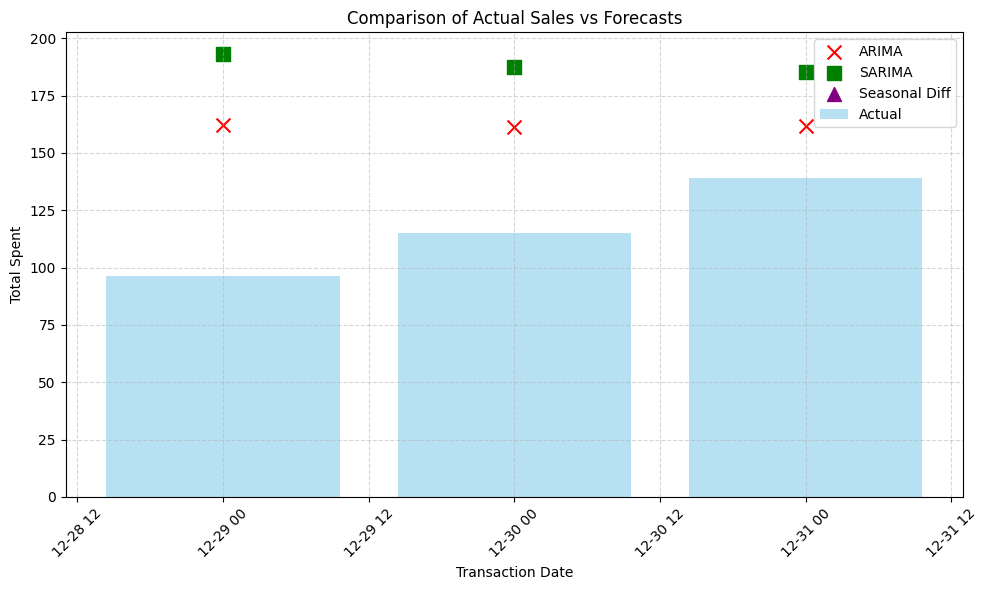

In [25]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# =========================
# قراءة البيانات وتجهيزها
# =========================
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# تجميع المبيعات حسب التاريخ
data = df.groupby('Transaction Date')['Total Spent'].sum()

# =========================
# تحسين 1: التحويل اللوغاريتمي لتقليل تأثير القيم الكبيرة والمتطرفة
# =========================
data_log = np.log1p(data)

# =========================
# تحسين 2: تقليل فترة الاختبار لآخر 3 أيام
# =========================
train, test = data_log[:-3], data_log[-3:]

# =========================
# تحسين 3: اختيار نطاق معاملات ARIMA منطقية لتجنب تعقيد النموذج
# =========================
best_mse = float('inf')
best_model = None
best_order = None

for p, d, q in [(0,1,1), (1,1,0), (1,1,1), (2,1,1)]:
    try:
        model = ARIMA(train, order=(p, d, q)).fit()
        forecast = model.forecast(steps=3)
        mse = mean_squared_error(test, forecast)
        if mse < best_mse:
            best_mse = mse
            best_model = model
            best_order = (p, d, q)
    except:
        pass

print("Best ARIMA order:", best_order)
print("Lowest MSE:", best_mse)

# =========================
# تحسين 4: إضافة مكون موسمي باستخدام SARIMA (لمراعاة التذبذب الأسبوعي)
# =========================
seasonal_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7)).fit()
seasonal_forecast = seasonal_model.forecast(steps=3)
seasonal_mse = mean_squared_error(test, seasonal_forecast)
print("Seasonal MSE:", seasonal_mse)

# =========================
# تحسين 5: استخدام الفارق الموسمي لتثبيت السلسلة أكثر (فرق أسبوعي)
# =========================
data_log_diff = data_log.diff(7).dropna()
train_diff, test_diff = data_log_diff[:-3], data_log_diff[-3:]

model_diff = ARIMA(train_diff, order=(1,1,1)).fit()
forecast_diff = model_diff.forecast(steps=3)
# إعادة تحويل القيم إلى المستوى الأصلي
forecast_diff_values = np.expm1(forecast_diff + data_log.shift(7).iloc[-3:])
print("Forecast after seasonal differencing:", forecast_diff_values)

# =========================
# تحسين 6: التحقق المتقاطع الزمني (Time Series Cross-Validation)
# =========================
def rolling_forecast(data_log, p, d, q, steps=3):
    errors = []
    predictions = []
    for i in range(len(data_log) - steps):
        train_cv = data_log[:i+steps]
        test_cv = data_log[i+steps:i+steps+steps]
        if len(test_cv) < steps:
            break
        try:
            model_cv = ARIMA(train_cv, order=(p,d,q)).fit()
            forecast_cv = model_cv.forecast(steps=steps)
            predictions.append(forecast_cv.values[-1])
            errors.append(mean_squared_error(test_cv, forecast_cv))
        except:
            continue
    return np.mean(errors), predictions

cv_mse, cv_predictions = rolling_forecast(data_log, 1,1,1)
print("Cross-Validation MSE:", cv_mse)


comparison_df.index = pd.to_datetime(comparison_df.index)

# =========================
# رسم بياني أعمدة مع نقاط التنبؤ
# =========================
plt.figure(figsize=(10,6))

# رسم الأعمدة للقيم الفعلية
plt.bar(comparison_df.index, comparison_df['Actual'], color='skyblue', label='Actual', alpha=0.6)

# رسم نقاط التنبؤ لكل تحسين
plt.scatter(comparison_df.index, comparison_df['ARIMA'], color='red', marker='x', s=100, label='ARIMA')
plt.scatter(comparison_df.index, comparison_df['SARIMA'], color='green', marker='s', s=100, label='SARIMA')
plt.scatter(comparison_df.index, comparison_df['Seasonal_Diff'], color='purple', marker='^', s=100, label='Seasonal Diff')

plt.title('Comparison of Actual Sales vs Forecasts')
plt.xlabel('Transaction Date')
plt.ylabel('Total Spent')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)  # لتسهيل قراءة التواريخ
plt.tight_layout()
plt.show()

# تحسين خوارزمية K means

Best K: 8
K-Means Inertia: 2240.959398210912
Silhouette Score: 0.49076683524310155


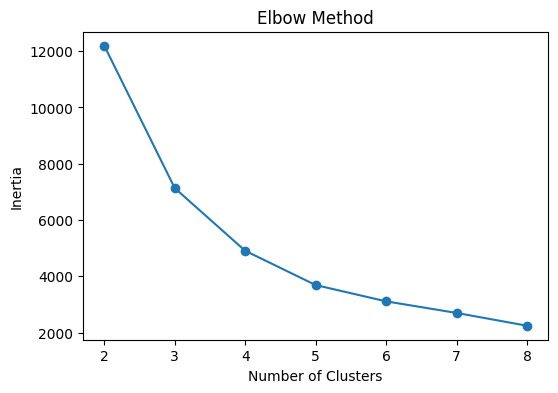

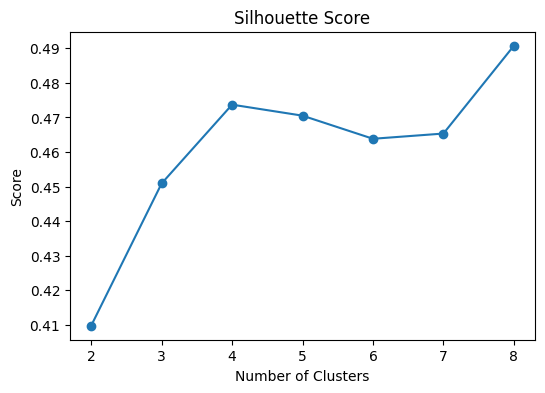

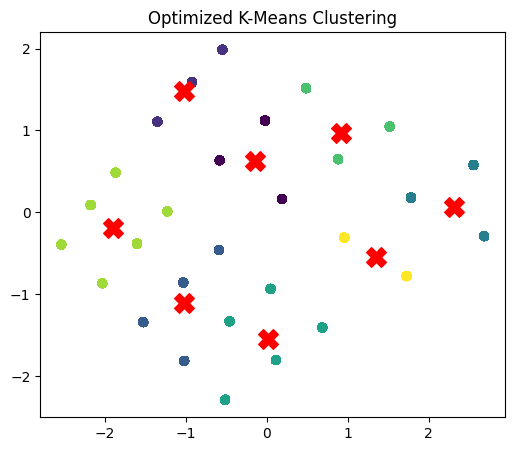

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# تحميل البيانات
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# تحسين 1: إنشاء ميزات جديدة تعبّر عن القيمة الشرائية لتقليل التشتت داخل الكلاسترات
df['Total_Value'] = df['Quantity'] * df['Price Per Unit']
df['Price_Log'] = np.log1p(df['Price Per Unit'])

# تحسين 2: اختيار المتغيرات الأقوى فقط للتجميع وتقليل الضوضاء
X = df[['Quantity', 'Total_Value', 'Price_Log']]

# تحسين 3: حذف القيم الشاذة لتقليل قيمة Inertia وتحسين جودة الفصل
z = np.abs((X - X.mean()) / X.std())
X = X[(z < 2.5).all(axis=1)]

# تحسين 4: التقييس لتوحيد المقياس ومنع سيطرة متغير على آخر
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تحسين 5: استخدام PCA لتقليل الأبعاد وإزالة الضوضاء وتجميع النقاط المتشابهة
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# تحسين 6: تجربة عدة قيم لـ K لاختيار العدد الأفضل بناءً على Silhouette
inertia = []
silhouette = []
K_range = range(2, 9)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=100)  # n_init عالي للوصول لأفضل حل
    labels = model.fit_predict(X_pca)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_pca, labels))

# تحسين 7: اختيار أفضل K يحقق أعلى Silhouette بدلاً من اختيار قيمة عشوائية
best_k = K_range[np.argmax(silhouette)]

# تحسين 8: تدريب النموذج النهائي بأفضل عدد كلاسترات للحصول على أقل Inertia
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels = kmeans.fit_predict(X_pca)

print("Best K:", best_k)
print("K-Means Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_pca, labels))

# تحسين 9: رسم Elbow Method لمعرفة نقطة الانكسار وتقليل عدد الكلاسترات
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# تحسين 10: رسم Silhouette Score لاختيار أفضل K بصريًا
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

# تحسين 11: رسم الكلاسترات مع المراكز لفهم تقسيم بيانات مبيعات المقهى
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', s=200, marker='X')
plt.title("Optimized K-Means Clustering")
plt.show()